In [288]:
import os
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
import seaborn as sns
import numpy as np
import scipy.signal as signal
import neurokit2 as nk 

folder_path = r'C:\Users\rusha\Desktop\Uni_Freiburg_Notes\MDD\pilot\abstract_images'
sensors = ['accelerometer', 'bvp', 'eda', 'systolicPeaks', 'temperature']

subject_dataframes = {subject: {sensor: pd.DataFrame() for sensor in sensors} for subject in ['1', '2', '3']}

for subject_folder in os.listdir(folder_path):
    subject_path = os.path.join(folder_path, subject_folder)
    if os.path.isdir(subject_path) and subject_folder in subject_dataframes:
        for sensor in sensors:
            file_path = os.path.join(subject_path, f'{sensor}.csv')
            if os.path.isfile(file_path):
                df = pd.read_csv(file_path)
                df['subject'] = subject_folder
                df['sensor'] = sensor
         
                subject_dataframes[subject_folder][sensor] = df

# subject 1:
df_accelerometer_1 = subject_dataframes['1']['accelerometer']
df_bvp_1 = subject_dataframes['1']['bvp']
df_eda_1 = subject_dataframes['1']['eda']
df_temperature_1 = subject_dataframes['1']['temperature']

# subject 2:
df_accelerometer_2 = subject_dataframes['2']['accelerometer']
df_bvp_2 = subject_dataframes['2']['bvp']
df_eda_2 = subject_dataframes['2']['eda']
df_temperature_2 = subject_dataframes['2']['temperature']

# subject 3:
df_accelerometer_3 = subject_dataframes['3']['accelerometer']
df_bvp_3 = subject_dataframes['3']['bvp']
df_eda_3 = subject_dataframes['3']['eda']
df_temperature_3 = subject_dataframes['3']['temperature']


In [289]:
def merge_dataframes(dfs, on='time'):
    result = dfs.pop(0)
    for df in dfs:
        result = pd.merge(result, df, on=on, how='outer', suffixes=('', '_dup'))
        result = result.loc[:, ~result.columns.duplicated()]
    return result

combined_dataframes = {}
for subject, dfs in subject_dataframes.items():
    for sensor, df in dfs.items():
        if 'time' not in df.columns:
            df['time'] = pd.to_datetime(df.index, unit='s')

    combined_df = pd.concat(list(dfs.values()))

    combined_dataframes[subject] = combined_df


df_combined_1 = combined_dataframes['1']
df_combined_2 = combined_dataframes['2']
df_combined_3 = combined_dataframes['3']

In [155]:
# df_accelerometer_1 = df_accelerometer_1.drop(columns=['subject', 'sensor'])
# df_accelerometer_2 = df_accelerometer_2.drop(columns=['subject', 'sensor'])
# df_accelerometer_3 = df_accelerometer_3.drop(columns=['subject', 'sensor'])
# df_bvp_1 = df_bvp_1.drop(columns=['subject', 'sensor'])
# df_bvp_2 = df_bvp_2.drop(columns=['subject', 'sensor'])
# df_bvp_3 = df_bvp_3.drop(columns=['subject', 'sensor'])
# df_eda_1 = df_eda_1.drop(columns=['subject', 'sensor'])
# df_eda_2 = df_eda_2.drop(columns=['subject', 'sensor'])
# df_eda_3 = df_eda_3.drop(columns=['subject', 'sensor'])
# df_temperature_1 = df_temperature_1.drop(columns=['subject', 'sensor'])
# df_temperature_2 = df_temperature_2.drop(columns=['subject', 'sensor'])
# df_temperature_3 = df_temperature_3.drop(columns=['subject', 'sensor'])

### ANOVA for subject 1

In [156]:
f_val, p_val = f_oneway(df_accelerometer_1['x'], df_accelerometer_1['y'], df_accelerometer_1['z'], df_bvp_1['values'], df_eda_1['values'], df_temperature_1['values'])
print(f"F-statistic: {f_val}, p-value: {p_val}")

F-statistic: 94168.84406999334, p-value: 0.0


### ANOVA for subject 2

In [157]:
f_val, p_val = f_oneway(df_accelerometer_2['x'], df_accelerometer_2['y'], df_accelerometer_2['z'], df_bvp_2['values'], df_eda_2['values'], df_temperature_2['values'])
print(f"F-statistic: {f_val}, p-value: {p_val}")

F-statistic: 13243.215568251724, p-value: 0.0


ANOVA for subject 3

In [158]:
f_val, p_val = f_oneway(df_accelerometer_3['x'], df_accelerometer_3['y'], df_accelerometer_3['z'], df_bvp_3['values'], df_eda_3['values'], df_temperature_3['values'])
print(f"F-statistic: {f_val}, p-value: {p_val}")

F-statistic: 4916.11746402607, p-value: 0.0


ANOVA accelerometer across subjects

In [159]:
f_val, p_val = f_oneway(df_accelerometer_3['x'], df_accelerometer_3['y'], df_accelerometer_3['z'], df_accelerometer_2['x'], df_accelerometer_2['y'], df_accelerometer_2['z'], df_accelerometer_1['x'], df_accelerometer_1['y'], df_accelerometer_1['z'])
print(f"F-statistic: {f_val}, p-value: {p_val}")

F-statistic: 12688.377708564385, p-value: 0.0


ANOVA EDA across subjects

In [160]:
f_val, p_val = f_oneway(df_eda_1['values'], df_eda_2['values'], df_eda_3['values'])
print(f"F-statistic: {f_val}, p-value: {p_val}")

F-statistic: 73006.02529914225, p-value: 0.0


ANOVA BVP across subjects

In [161]:
f_val, p_val = f_oneway(df_bvp_1['values'], df_bvp_2['values'], df_bvp_3['values'])
print(f"F-statistic: {f_val}, p-value: {p_val}")

F-statistic: 0.013806798657478856, p-value: 0.9862880882039736


ANOVA temp across subjects

In [162]:
f_val, p_val = f_oneway(df_temperature_1['values'], df_temperature_2['values'], df_temperature_3['values'])
print(f"F-statistic: {f_val}, p-value: {p_val}")

F-statistic: 11396.099565408746, p-value: 2.1012063229653848e-273


# Heart Rate Variability

In [290]:
# detect peaks
peaks, _ = signal.find_peaks(df_bvp_1['values'], height=None, distance=64*0.6)  # 0.6s is typically minimum distance between peaks
# calculate interbeat Intervals
ibi = np.diff(peaks) / 64.0  # convert sample differences to seconds
# HRV analysis
hrv_metrics_1 = nk.hrv_time(peaks, sampling_rate=64)

# detect peaks
peaks, _ = signal.find_peaks(df_bvp_2['values'], height=None, distance=64*0.6)  # 0.6s is typically minimum distance between peaks
# calculate interbeat Intervals
ibi = np.diff(peaks) / 64.0  # convert sample differences to seconds
# HRV analysis
hrv_metrics_2 = nk.hrv_time(peaks, sampling_rate=64)

# detect peaks
peaks, _ = signal.find_peaks(df_bvp_3['values'], height=None, distance=64*0.6)  # 0.6s is typically minimum distance between peaks
# calculate interbeat Intervals
ibi = np.diff(peaks) / 64.0  # convert sample differences to seconds
# HRV analysis
hrv_metrics_3 = nk.hrv_time(peaks, sampling_rate=64)

# combine HRV metrics
hrv_combined = pd.concat([hrv_metrics_1, hrv_metrics_2, hrv_metrics_3], axis=0)
hrv_combined.index = ['Subject 1', 'Subject 2', 'Subject 3']

In [255]:
# detect peaks
def detect_peaks(bvp_signal, sampling_rate=64):
    peak_data = nk.ppg_findpeaks(bvp_signal, sampling_rate=sampling_rate, method="elgendi")
    return peak_data['PPG_Peaks']

# compute RR intervals
def compute_rr_intervals(peaks, sampling_rate=64):
    if len(peaks) > 1:
        rr_intervals = np.diff(peaks) / sampling_rate  # Convert to seconds
        return rr_intervals
    else:
        return []

def calculate_rr_variance(rr_intervals):
    if len(rr_intervals) > 1:
        # calculate variance of RR intervals
        variance_rr_intervals = np.var(rr_intervals)
        return variance_rr_intervals
    else:
        return np.nan


# subject 1
bvp_signal = df_bvp_1['values']

peaks = detect_peaks(bvp_signal)
print("Detected Peaks:", peaks)

rr_intervals = compute_rr_intervals(peaks)
print("RR Intervals:", rr_intervals)

hrv_1 = calculate_rr_variance(rr_intervals)
print(f"Variance of RR Intervals: {hrv_1}")

# subject 2
bvp_signal = df_bvp_2['values']

peaks = detect_peaks(bvp_signal)
print("Detected Peaks:", peaks)

rr_intervals = compute_rr_intervals(peaks)
print("RR Intervals:", rr_intervals)

hrv_2 = calculate_rr_variance(rr_intervals)
print(f"Variance of RR Intervals: {hrv_1}")

# subject 3
bvp_signal = df_bvp_3['values']

peaks = detect_peaks(bvp_signal)
print("Detected Peaks:", peaks)

rr_intervals = compute_rr_intervals(peaks)
print("RR Intervals:", rr_intervals)

hrv_3 = calculate_rr_variance(rr_intervals)
print(f"Variance of RR Intervals: {hrv_1}")


Detected Peaks: [ 135  211  325  450  570  658  698  742  830  863  908  949  992 1032
 1113 1145 1266 1310 1352 1440 1478 1580 1710 1770 1790 1877 1903 1990
 2033 2140 2217 2331 2486 2525 2704 2747 2788 2830 2871 2913 2955 2998
 3042 3089 3138 3187 3235 3281 3329 3373 3418 3462 3507 3553 3601 3650
 3697 3744 3792 3840 3888 3934 3981 4029 4077 4125 4172 4218 4262 4307
 4352 4401 4448 4493 4539 4585 4629 4676 4724 4772 4823 4874 4925 4975
 5026 5074 5124 5170 5217 5264 5309 5356 5405 5455 5506 5558 5611 5661
 5711 5758 5806 5855 5903 5950 5999 6050 6101 6150 6200 6250]
RR Intervals: [1.1875   1.78125  1.953125 1.875    1.375    0.625    0.6875   1.375
 0.515625 0.703125 0.640625 0.671875 0.625    1.265625 0.5      1.890625
 0.6875   0.65625  1.375    0.59375  1.59375  2.03125  0.9375   0.3125
 1.359375 0.40625  1.359375 0.671875 1.671875 1.203125 1.78125  2.421875
 0.609375 2.796875 0.671875 0.640625 0.65625  0.640625 0.65625  0.65625
 0.671875 0.6875   0.734375 0.765625 0.765625 0.75  

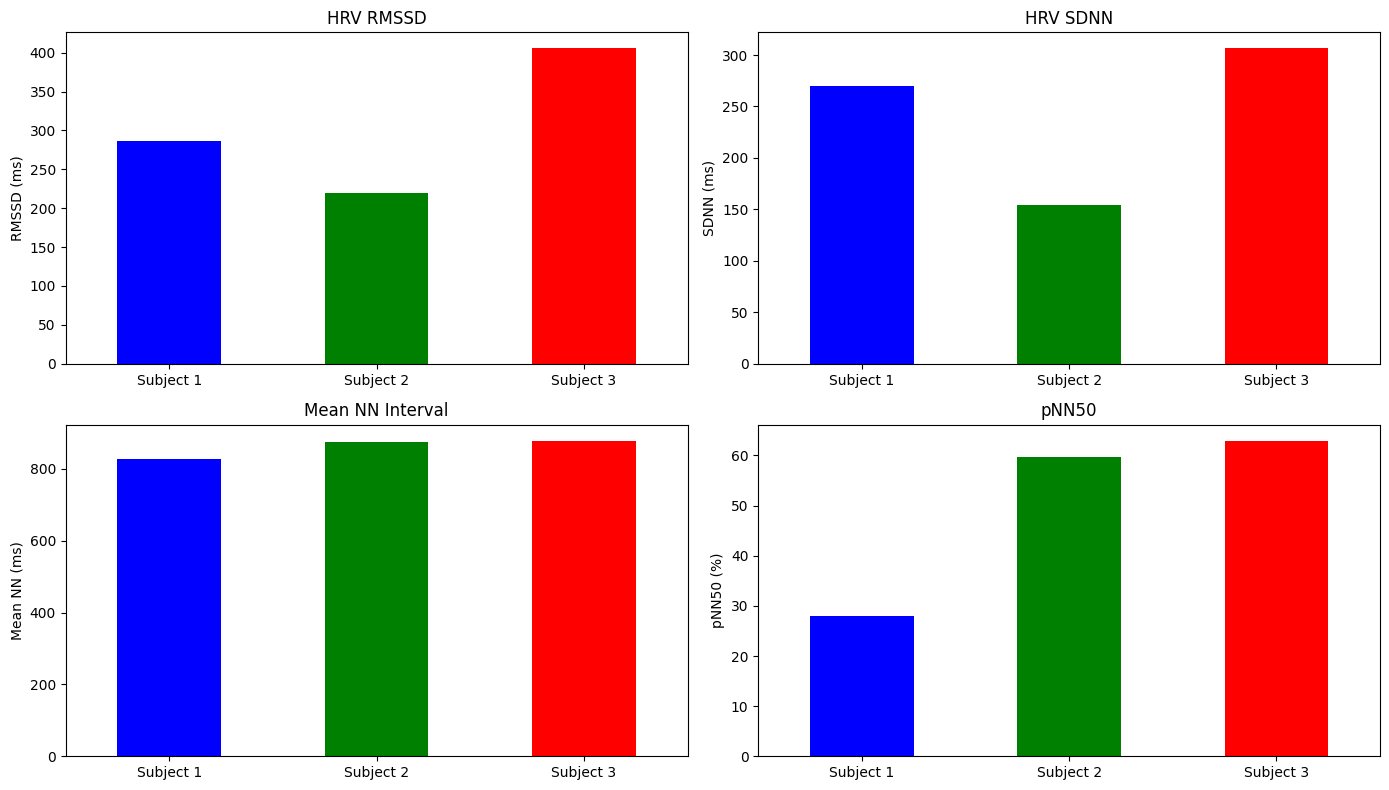

In [291]:
import matplotlib.pyplot as plt
# Plot comparison for key HRV metrics
plt.figure(figsize=(14, 8))

# Plot RMSSD
plt.subplot(2, 2, 1)
hrv_combined['HRV_RMSSD'].plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('HRV RMSSD')
plt.ylabel('RMSSD (ms)')
plt.xticks(rotation=0)

# Plot SDNN
plt.subplot(2, 2, 2)
hrv_combined['HRV_SDNN'].plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('HRV SDNN')
plt.ylabel('SDNN (ms)')
plt.xticks(rotation=0)

# Plot MeanNN
plt.subplot(2, 2, 3)
hrv_combined['HRV_MeanNN'].plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Mean NN Interval')
plt.ylabel('Mean NN (ms)')
plt.xticks(rotation=0)

# Plot pNN50
plt.subplot(2, 2, 4)
hrv_combined['HRV_pNN50'].plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('pNN50')
plt.ylabel('pNN50 (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# Variances

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


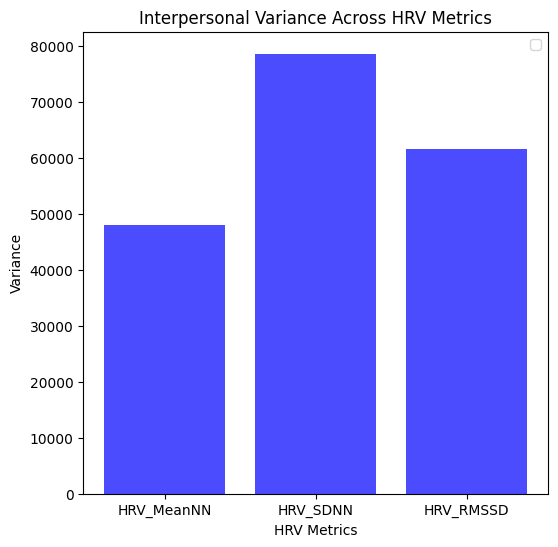

C:\Users\rusha\AppData\Local\Temp\ipykernel_19400\2224215733.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hrv_combined.index, y=intrapersonal_variance, palette='viridis')


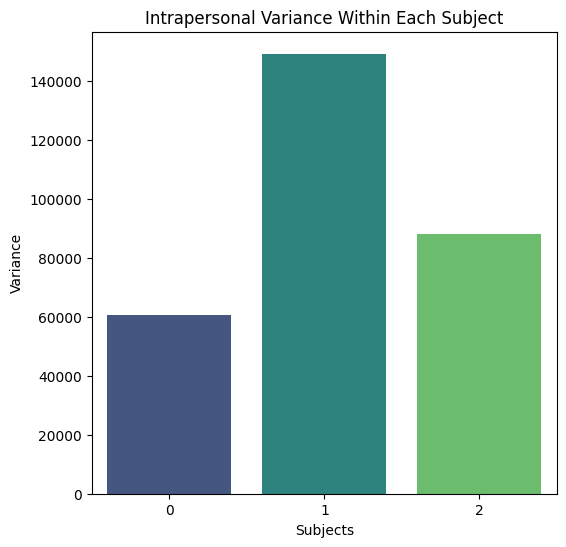

In [172]:
# Example HRV metrics data for three subjects (rows) and different HRV metrics (columns)
hrv_combined = pd.DataFrame({
    'HRV_MeanNN': [hrv_combined['HRV_MeanNN']['Subject 1'], hrv_combined['HRV_MeanNN']['Subject 2'], hrv_combined['HRV_MeanNN']['Subject 3']],
    'HRV_SDNN': [hrv_combined['HRV_SDNN']['Subject 1'], hrv_combined['HRV_SDNN']['Subject 2'], hrv_combined['HRV_SDNN']['Subject 3']],
    'HRV_RMSSD': [hrv_combined['HRV_RMSSD']['Subject 1'], hrv_combined['HRV_RMSSD']['Subject 2'], hrv_combined['HRV_SDNN']['Subject 3']]
})

# Calculate intrapersonal and interpersonal variances
intrapersonal_variance = hrv_combined.var(axis=1)
interpersonal_variance = hrv_combined.var(axis=0)

# Plotting interpersonal variance
plt.figure(figsize=(6, 6))
plt.bar(hrv_combined.columns, interpersonal_variance, alpha=0.7, color='blue')
plt.xlabel('HRV Metrics')
plt.ylabel('Variance')
plt.title('Interpersonal Variance Across HRV Metrics')
plt.legend()
plt.show()

# Plotting intrapersonal variance
plt.figure(figsize=(6, 6))
sns.barplot(x=hrv_combined.index, y=intrapersonal_variance)
plt.xlabel('Subjects')
plt.ylabel('Variance')
plt.title('Intrapersonal Variance Within Each Subject')
plt.show()


In [257]:
# Calculate intrapersonal variance for each subject and modality
intra_variance_bvp_1 = df_bvp_1['values'].var()
intra_variance_eda_1 = df_eda_1['values'].var()
intra_variance_temp_1 = df_temperature_1['values'].var()

intra_variance_bvp_2 = df_bvp_2['values'].var()
intra_variance_eda_2 = df_eda_2['values'].var()
intra_variance_temp_2 = df_temperature_2['values'].var()

intra_variance_bvp_3 = df_bvp_3['values'].var()
intra_variance_eda_3 = df_eda_3['values'].var()
intra_variance_temp_3 = df_temperature_3['values'].var()

intra_variance_bvp_3 = df_bvp_3['values'].var()
intra_variance_eda_3 = df_eda_3['values'].var()
intra_variance_temp_3 = df_temperature_3['values'].var()



# Combine intrapersonal variances into a DataFrame for easier visualization
intrapersonal_variances = pd.DataFrame({
    'Subject 1': {'HRV': hrv_1, 'BVP': intra_variance_bvp_1, 'EDA': intra_variance_eda_1, 'Temperature': intra_variance_temp_1},
    'Subject 2': {'HRV': hrv_2, 'BVP': intra_variance_bvp_2, 'EDA': intra_variance_eda_2, 'Temperature': intra_variance_temp_2},
    'Subject 3': {'HRV': hrv_3, 'BVP': intra_variance_bvp_3, 'EDA': intra_variance_eda_3, 'Temperature': intra_variance_temp_3}
})

intrapersonal_variances

,Subject 1,Subject 2,Subject 3
HRV,0.164035,0.037137,0.554219
BVP,0.001733,0.004034,0.002167
EDA,0.000003,0.000005,0.001000
Temperature,0.000114,0.001689,0.007707


In [292]:
print(interpersonal_variances)

HRV            7.262008e-02
BVP            1.494774e-06
EDA            3.306730e-07
Temperature    1.605843e-05
dtype: float64


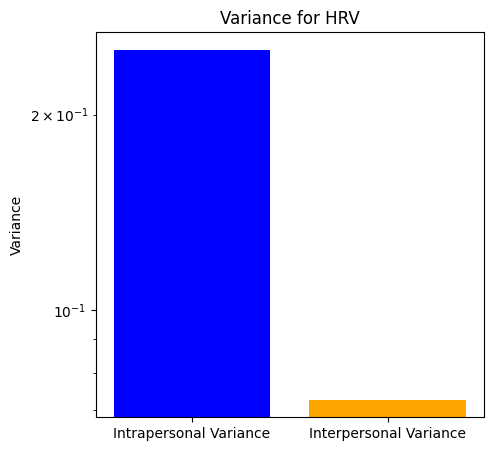

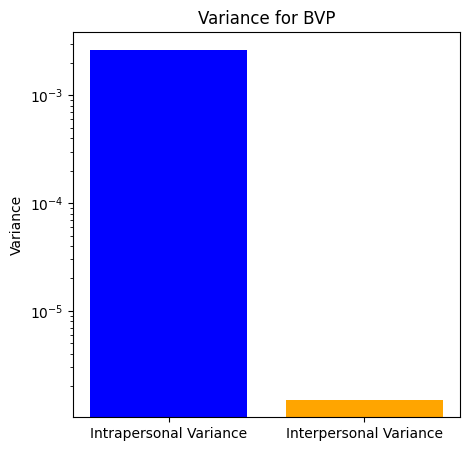

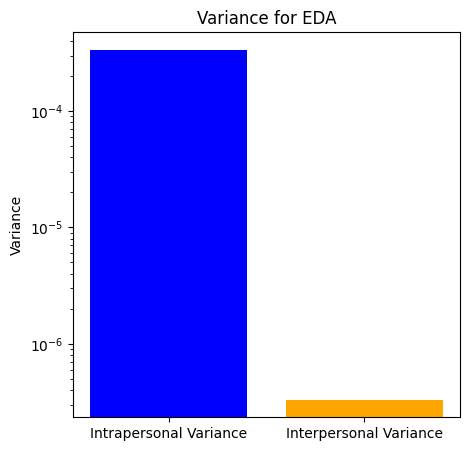

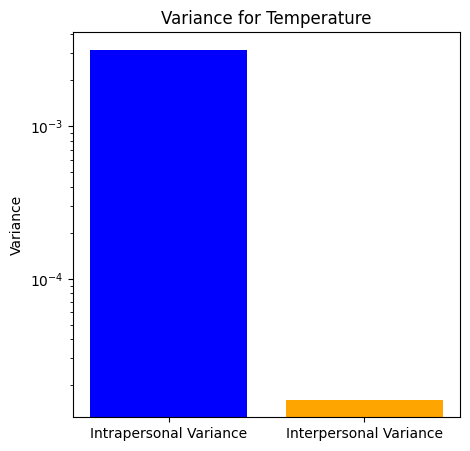

In [293]:
# Calculate interpersonal variance for each metric
interpersonal_variances = intrapersonal_variances.var(axis=1)

# Calculate the mean of intrapersonal variances for each metric
intrapersonal_mean = intrapersonal_variances.mean(axis=1)

# Create separate bar charts for each metric
metrics = intrapersonal_variances.index

for metric in metrics:
    plt.figure(figsize=(5, 5))
    
    # Bar chart data
    data = {
        'Intrapersonal Variance': intrapersonal_mean[metric],
        'Interpersonal Variance': interpersonal_variances[metric]
    }
    
    # Plotting
    plt.bar(data.keys(), data.values(), color=['blue', 'orange'])
    plt.title(f'Variance for {metric}')
    plt.ylabel('Variance')
    plt.yscale('log')  # log scaling
    
    plt.show()

In [275]:
print(intrapersonal_variances)

             Subject 1  Subject 2  Subject 3
HRV           0.164035   0.037137   0.554219
BVP           0.001733   0.004034   0.002167
EDA           0.000003   0.000005   0.001000
Temperature   0.000114   0.001689   0.007707


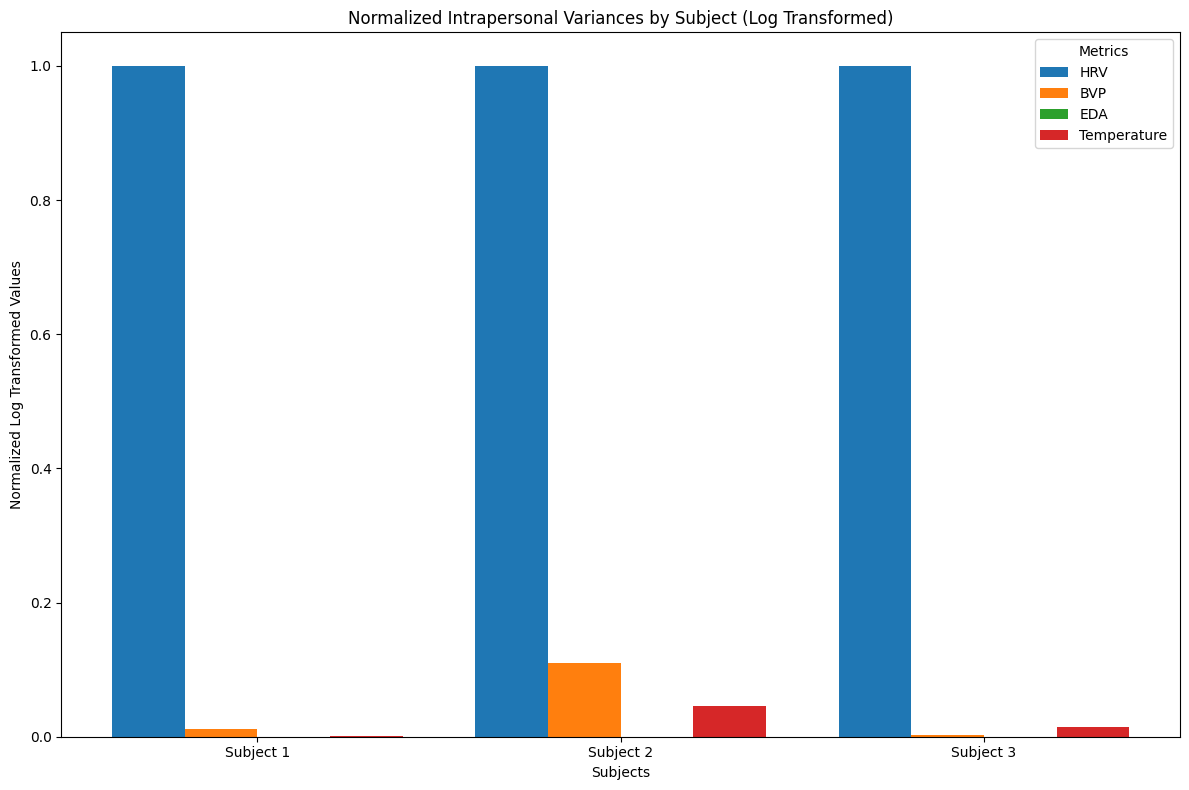

In [278]:
# Apply log transformation (adding a small constant to avoid log(0))
log_transformed_df = np.log1p(intrapersonal_variances)

# Normalize the log-transformed data
normalized_log_df = min_max_normalize(log_transformed_df)

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(normalized_log_df.columns))
for i, metric in enumerate(normalized_log_df.index):
    ax.bar(x + i * bar_width, normalized_log_df.loc[metric], bar_width, label=metric)
ax.set_xlabel('Subjects')
ax.set_ylabel('Normalized Log Transformed Values')
ax.set_title('Normalized Intrapersonal Variances by Subject (Log Transformed)')
ax.set_xticks(x + bar_width * (len(normalized_log_df.index) - 1) / 2)
ax.set_xticklabels(normalized_log_df.columns)
ax.legend(title='Metrics')
plt.tight_layout()
plt.show()


In [176]:
# Calculate the mean values for each modality across subjects
mean_bvp = [df_bvp_1['values'].mean(), df_bvp_2['values'].mean(), df_bvp_3['values'].mean()]
mean_eda = [df_eda_1['values'].mean(), df_eda_2['values'].mean(), df_eda_3['values'].mean()]
mean_temp = [df_temperature_1['values'].mean(), df_temperature_2['values'].mean(), df_temperature_3['values'].mean()]
mean_hrv = [df_temperature_1['values'].mean(), df_temperature_2['values'].mean(), df_temperature_3['values'].mean()]
# Calculate interpersonal variance for each modality
inter_variance_bvp = np.var(mean_bvp)
inter_variance_eda = np.var(mean_eda)
inter_variance_temp = np.var(mean_temp)

# Combine interpersonal variances into a DataFrame for easier visualization
interpersonal_variances = pd.DataFrame({
    'BVP': [inter_variance_bvp],
    'EDA': [inter_variance_eda],
    'Temperature': [inter_variance_temp]
}, index=['Interpersonal Variance'])

interpersonal_variances

,BVP,EDA,Temperature
Interpersonal Variance,3.906697e-09,0.042072,0.248451


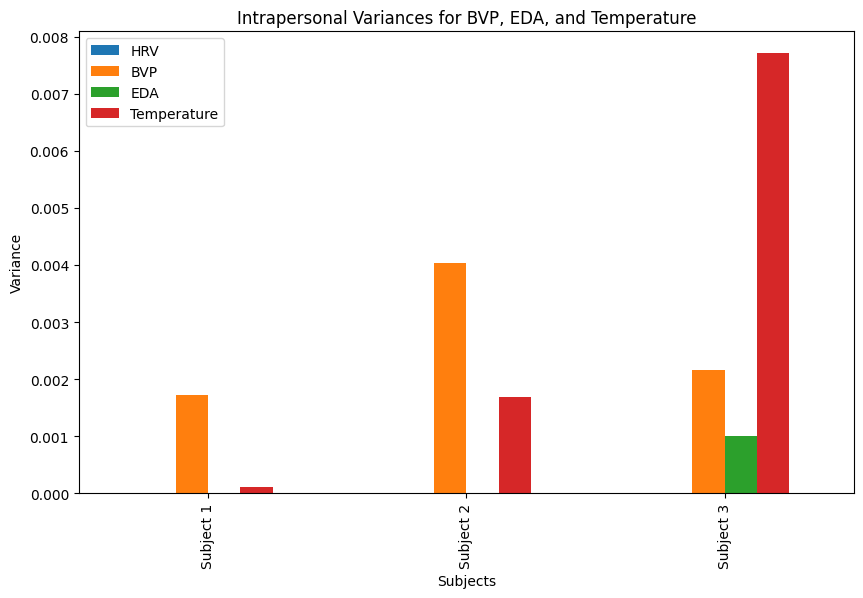

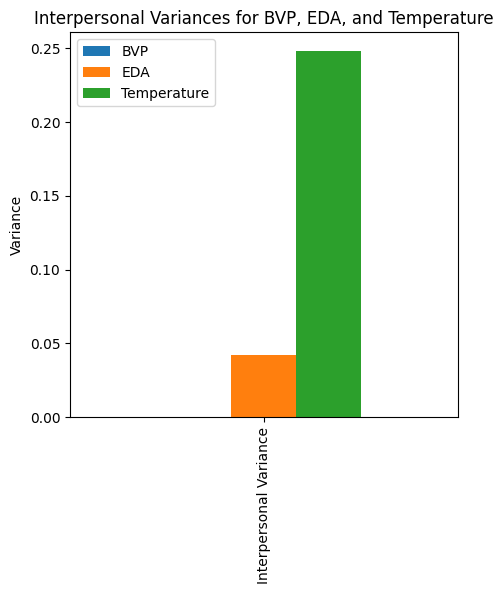

In [184]:
import matplotlib.pyplot as plt

# Plotting intrapersonal variances
intrapersonal_variances.T.plot(kind='bar', figsize=(10, 6))
plt.title('Intrapersonal Variances for BVP, EDA, and Temperature')
plt.ylabel('Variance')
plt.xlabel('Subjects')
plt.show()

# Plotting interpersonal variances
interpersonal_variances.plot(kind='bar', figsize=(5, 5))
plt.title('Interpersonal Variances for BVP, EDA, and Temperature')
plt.ylabel('Variance')
plt.show()
